In [17]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default='browser'
import pyarrow.feather as feather
import plotly.express as px
import numpy as np
import yaml


In [18]:
#load model parameters from yaml file
with open('Gonneville_pars.yaml', 'r') as file:
    model_params = yaml.safe_load(file)

#Access parameters


mineral = model_params['response']
covariates = model_params['covariates']


#model_params = model_params['model']

learning_rate = model_params['learning_rate']
batch_size = model_params['batch_size']
epochs = model_params['epochs']
cellsize = model_params['cellsize']
layers = model_params['layers']
dropout = model_params['dropout']
activation = model_params['activation']
loss = model_params['loss']
optimizer = model_params['optimizer']

x = model_params['x']
y = model_params['y']
z = model_params['z']

# plotting parameters
cov_labels = model_params['cov_labels']

# file paths
source_dir = model_params['source_dir']
working_dir = model_params['working_dir']
roi_dir = model_params['roi_dir']

In [19]:
gonneville_data = pd.read_csv(f'{source_dir}/Gonneville_full.csv', low_memory=False)  # Gonneville data
# load ROI coords
ROI = pd.read_csv(f'{roi_dir}/ROI.csv', low_memory=False)

In [20]:
# Assume ROI is a DataFrame with columns: Xmin, Xmax, Ymin, Ymax
# And gonneville_data has columns: mid_x_y, mid_y_y, mid_z_y

#small_ROI = 0
#medium_ROI = 1
#large_ROI = 2

roi_row = 0  # Change this to select the desired ROI row


xmin, xmax = ROI['Xmin'].iloc[roi_row], ROI['Xmax'].iloc[roi_row]
ymin, ymax = ROI['Ymin'].iloc[roi_row], ROI['Ymax'].iloc[roi_row]

filtered_gonneville = gonneville_data[
    (gonneville_data['mid_x_y'] >= xmin) & (gonneville_data['mid_x_y'] <= xmax) &
    (gonneville_data['mid_y_y'] >= ymin) & (gonneville_data['mid_y_y'] <= ymax)
]

In [21]:
#df = density_data.copy()
df = filtered_gonneville.copy()

#filtered_samples = df.dropna(subset=['Alt1_Code', 'Alt2_Code', 'Density_gcm3'])
#sample_list = Gonneville_pars(response+covariates) # TODO fix this with Yaml
filtered_samples = df.dropna(subset=['Pd_ppm', 'Pt_ppm', 'Ni_ppm', 'Co_ppm', 'Cr_ppm', 'Cu_ppm', 'Lith1_Code'])
cols = ['Pd_ppm', 'Pt_ppm', 'Ni_ppm', 'Co_ppm', 'Cr_ppm', 'Cu_ppm', 'Lith1_Code']
combined_data = df[cols].dropna()
#deposit_data = deposit_data.dropna

sample_count = len(filtered_samples)
perc = (sample_count/len(df))*100 
#print(f"Number of samples with alteration and Density_gcm3 data: {sample_count}")
#print(f"Number of samples with gold and pathfinder (As, Hg) data: {sample_count}")
print(f"Number of samples with Pd and 'important feature' (Pt_ppm, Ni_ppm, Co_ppm, Cr_ppm, Cu_ppm, Lith1_code) data: {sample_count}")
#print(f"This is " {perc} " percent of the dataset") 
print(perc)

Number of samples with Pd and 'important feature' (Pt_ppm, Ni_ppm, Co_ppm, Cr_ppm, Cu_ppm, Lith1_code) data: 20665
99.6768280918387


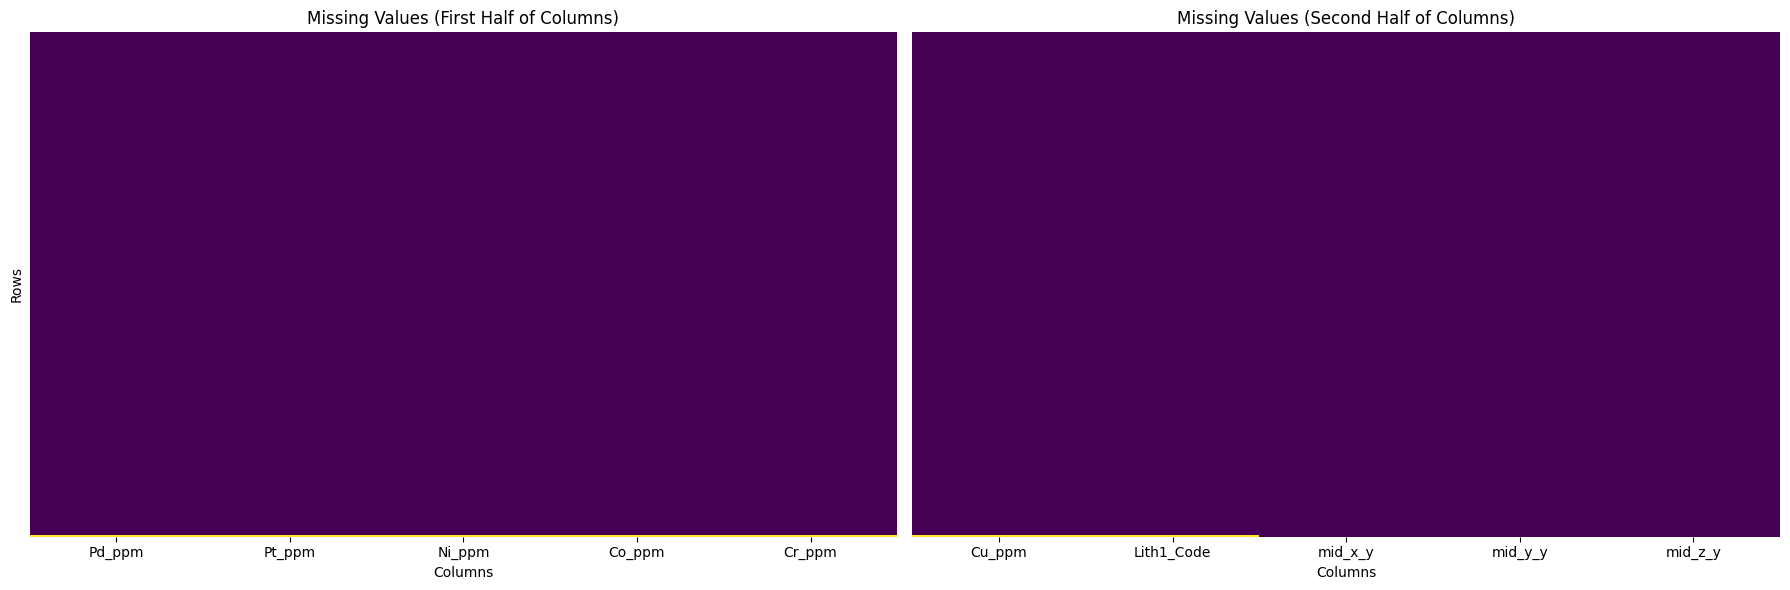

In [15]:
# Plot missing values in merged_df as two separate heatmaps: 
# 1. For the first half of columns, 2. For the second half

import matplotlib.pyplot as plt
import seaborn as sns

n_cols = combined_data.shape[1]
mid = n_cols // 2

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# First half of columns
sns.heatmap(
    combined_data.iloc[:, :mid].isnull(),
    cbar=False, yticklabels=False, cmap='viridis', ax=axes[0]
)
axes[0].set_title('Missing Values (First Half of Columns)')
axes[0].set_xlabel('Columns')
axes[0].set_ylabel('Rows')

# Second half of columns
sns.heatmap(
    combined_data.iloc[:, mid:].isnull(),
    cbar=False, yticklabels=False, cmap='viridis', ax=axes[1]
)
axes[1].set_title('Missing Values (Second Half of Columns)')
axes[1].set_xlabel('Columns')

plt.tight_layout()
plt.show()

In [ ]:
np.log(combined_data['Pd_ppm']+0.0000001)

In [22]:
# log transform the data
# TODO yaml
#deposit_data['Log_Pd_ppm'reponses] = np.log(deposit_data[Pd_ppm])

plot_data = combined_data.copy()
plot_data['Log_Pd_ppm'] = np.log(combined_data['Pd_ppm']+0.00001)
cols_to_add = ['mid_x_y', 'mid_y_y', 'mid_z_y']
plot_data = pd.concat([plot_data, filtered_gonneville[cols_to_add]], axis=1)

#TODO get all this from Yaml
# Create 3D scatter plot
fig = px.scatter_3d(plot_data, \
                    x='mid_x_y', y='mid_y_y', z='mid_z_y', \
                    #x='x', y='y', z='z', \ #YAML
                        color='Log_Pd_ppm', \
                        opacity=0.7, labels={'Log_Pd_ppm': 'Pd log(ppm)'})

fig.update_traces(marker=dict(line=dict(width=0)))
# Show plot
fig.show()

In [ ]:
# encoding
# Find columns with object or category dtype
categorical_cols = combined_data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_data = combined_data[categorical_cols]




#pd.get_dummies(deposit_data['Lith1_Code'])

In [ ]:
'''two_composite_1covariates = deposit_data

missing_percentage = (two_composite_1covariates.isnull().sum() / len(two_composite_1covariates)) * 100

variables_to_remove = missing_percentage[missing_percentage > 5].index

two_composite_1covariates = two_composite_1covariates.drop(columns=variables_to_remove)
'''
# Find columns with object or category dtype
categorical_cols = combined_data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_data = combined_data[categorical_cols]

encoded_data = categorical_data.copy()

threshold = 10

for column in categorical_data.columns:
    if categorical_data[column].dtype == 'object':
        unique_values = categorical_data[column].nunique()
        
        if unique_values <= threshold:
            encoded_columns = pd.get_dummies(encoded_data[column], prefix=column)
            encoded_columns = encoded_columns.astype(int)  
            encoded_data = pd.concat([encoded_data, encoded_columns], axis=1)
            encoded_data = encoded_data.drop(columns=[column])




encoded_columns = [col for col in encoded_data.columns if '_Code_' in col]

total_columns = []
'''
for col in encoded_columns:
    prefix, original_column = col.split('_Code_')
    
    total_column = f"{original_column}_Total"
    total_columns.append(total_column)
    
    encoded_data[total_column] = (
        encoded_data[f"{prefix}_Code_{original_column}"] * encoded_data[f"{prefix}_Pct"]
    )

total_columns = []

category_totals = {}

for col in encoded_columns:
    prefix, original_column = col.split('_Code_')
    
    total_column = f"{original_column}_Total"
    if total_column not in total_columns:
        total_columns.append(total_column)
    
    total_values = encoded_data[f"{prefix}_Code_{original_column}"] * encoded_data[f"{prefix}_Pct"]
    
    if total_column in category_totals:
        category_totals[total_column] += total_values
    else:
        category_totals[total_column] = total_values

for total_column, total_values in category_totals.items():
    encoded_data[total_column] = total_values
'''

In [ ]:
variables = [x] + [y] + [z] + [mineral] + [covariates]

#cov_labels = ['X (m)', 'Y (m)', 'Z (m)', 'Pyrite (%)', 'Pyrrhotite (%)', 'Chalcopyrite (%)', 'Chromium (ppm)', 'Rock-quality designation (%)', 'Density (g/cm3)']
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

for i, var in enumerate(variables):
    row = i // 3
    col = i % 3
    axs[row, col].hist(combined_data[var], bins=20, color='#C26DBC', edgecolor='black')
    axs[row, col].set_xlabel(str(cov_labels[i]))
    axs[row, col].set_ylabel('Frequency')
    axs[row, col].grid(False)
    if var == 'X':
        x_ticks = axs[row, col].get_xticks()
        x_ticks = x_ticks[::1]  
        axs[row, col].set_xticks(x_ticks)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# If your DataFrame is called gonneville_data:
combined_data['Lith1_Code'].hist(bins=30)  # Adjust bins as needed
plt.xlabel('Lith1_Code')
plt.ylabel('Frequency')
plt.title('Histogram of Lith1_Code')
plt.show()

In [ ]:
combined_data['Log_Au_ppm'] = np.log(combined_data['Au_ppm'])
combined_data['Log_As_ppm_BESTEL'] = np.log(combined_data['As_ppm_BESTEL'])
combined_data['Log_Hg_ppm_BESTEL'] = np.log(combined_data['Hg_ppm_BESTEL'])
columns = ['X', 'Y', 'Z', 'Log_Au_ppm', 'Log_As_ppm_BESTEL', 'Log_Hg_ppm_BESTEL']
scatter_matrix = pd.plotting.scatter_matrix(combined_data[columns], figsize=(30, 30))

#import seaborn as sns

# columns = ['X', 'Y', 'Z', 'CP_Total', 'PO_Total', 'PY_Total', 'RQD_Pct', 'Cr_ppm', 'Density_gcm3']
# sns.pairplot(deposit_data[columns], diag_kind='kde', corner=True)

In [ ]:
summary = combined_data.describe().round(3)

latex_table = summary.to_latex()

In [8]:
# export unnormalised deposit data
combined_data = pd.concat([combined_data, filtered_gonneville[cols_to_add]], axis=1)


In [ ]:

combined_data.to_csv(f'{working_dir}/filtered_unnormalised_deposit_data.csv', index=False)




In [9]:
columns_to_normalize = [x] + [y] + [z]

min_values = combined_data[columns_to_normalize].min()

for column in columns_to_normalize:
    combined_data[column] = combined_data[column] - min_values[column]

# Calculate the minimum and maximum values from all three variables
min_values = combined_data[columns_to_normalize].min().min()
max_values = combined_data[columns_to_normalize].max().max()

for column in columns_to_normalize:
    combined_data[column] = (combined_data[column] - min_values) / (max_values - min_values)


In [13]:

#Scale the rest of the covariates in their own scale
#covariates = ['As_ppm_BESTEL', 'Hg_ppm_BESTEL']
# delete 'log' columns that were used for visualisation
delete_cols = ['Log_Pd_ppm']

try:
    combined_data = combined_data.drop(columns=delete_cols, axis=1)
except Exception:
    pass


exclude_cols = [[x] + [y] + [z]] # exclude x, y, z from scaling as they are coordinates and have been normalized
numeric_cols = combined_data.select_dtypes(include='number').columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

print(numeric_cols)

scaler = MinMaxScaler()
combined_data.loc[:, numeric_cols] = scaler.fit_transform(combined_data.loc[:,numeric_cols])


['Pd_ppm', 'Pt_ppm', 'Ni_ppm', 'Co_ppm', 'Cr_ppm', 'Cu_ppm', 'mid_x_y', 'mid_y_y', 'mid_z_y']


In [ ]:
all_indexes = combined_data.index
all_indexes.to_series().to_csv('C:/Users/lin236/Documents/DK_Data_PC/indexes.csv', index=False)


In [12]:
#deposit_data.to_csv('C:/Users/lin236/Documents/DK_Data_PC/filtered_deposit_data.csv', index=False)
path = f"{working_dir}/combined_data.csv"
combined_data.to_csv(path, index=False)

In [ ]:
combined_data.values[:, 8]